In [1]:
!pip install catboost xgboost shap scikit-learn pandas numpy

import pandas as pd
import numpy as np
import shap
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
from xgboost import XGBClassifier
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

np.random.seed(42)

df['los'] = df['tenure']
df['poin'] = (df['los'] * 15) + np.random.normal(0, 50, len(df))
df['poin'] = df['poin'].clip(lower=0)

df['avg_3m'] = df['MonthlyCharges'] + np.random.normal(0, 5, len(df))
df['avg_3m_std'] = df['MonthlyCharges'] * np.random.uniform(0.05, 0.2, len(df))

categorical_cols = df.select_dtypes(include=['object']).columns.drop(['customerID', 'Churn'])
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df['Churn_Label'] = df['Churn'].map({'Yes': 1, 'No': 0})

features = ['los', 'poin', 'avg_3m', 'avg_3m_std', 'TotalCharges'] + list(categorical_cols)
X = df[features]
y_churn = df['Churn_Label']

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.0 MB/s eta 0:00:00


In [2]:
X_train, X_test, y_train, y_test = train_test_split(X, y_churn, test_size=0.2, stratify=y_churn, random_state=42)

print("Phase 1: Training Churn Risk Model")

xgb = XGBClassifier(eval_metric='logloss', random_state=42)
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 1.0]
}

xgb_search = RandomizedSearchCV(xgb, param_distributions=param_grid, n_iter=10, scoring='roc_auc', cv=5, random_state=42)
xgb_search.fit(X_train, y_train)

best_xgb = xgb_search.best_estimator_

churn_preds = best_xgb.predict(X_test)
churn_probs = best_xgb.predict_proba(X_test)[:, 1]

print(f"Best Params: {xgb_search.best_params_}")
print(f"ROC-AUC: {roc_auc_score(y_test, churn_probs):.3f}")
print(f"F1-Score: {f1_score(y_test, churn_preds):.3f}")

df['predicted_churn_prob'] = best_xgb.predict_proba(X)[:, 1]

Phase 1: Training Churn Risk Model
Best Params: {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}
ROC-AUC: 0.833
F1-Score: 0.560


In [3]:
print("Phase 2: Calculating Risk-Adjusted Revenue")

WACC_median = 0.078
expected_market_churn = df['predicted_churn_prob'].mean()

df['discount_rate'] = WACC_median * (df['predicted_churn_prob'] / expected_market_churn)

df['RAR'] = df['TotalCharges'] / (1 + df['discount_rate'])

print("Sample of calculated financial metrics:")
display(df[['TotalCharges', 'predicted_churn_prob', 'discount_rate', 'RAR']].head())

Phase 2: Calculating Risk-Adjusted Revenue
Sample of calculated financial metrics:


,TotalCharges,predicted_churn_prob,discount_rate,RAR
0,29.85,0.698990,0.203754,24.797419
1,1889.50,0.038064,0.011095,1868.765073
2,108.15,0.266849,0.077786,100.344609
3,1840.75,0.054986,0.016028,1811.711374
4,151.65,0.623777,0.181830,128.317981


In [4]:
print("Phase 3: Training RAR Prediction Model")

X_rar = df[features + ['predicted_churn_prob']]
y_rar = df['RAR']

X_r_train, X_r_test, y_r_train, y_r_test = train_test_split(X_rar, y_rar, test_size=0.2, random_state=42)

cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    verbose=0,
    random_state=42
)

cat_model.fit(X_r_train, y_r_train)
rar_preds = cat_model.predict(X_r_test)

mape = mean_absolute_percentage_error(y_r_test, rar_preds) * 100
rmse = np.sqrt(mean_squared_error(y_r_test, rar_preds))
r2 = r2_score(y_r_test, rar_preds)

print(f"MAPE: {mape:.2f}%")
print(f"RMSE: {rmse:.2f}")
print(f"R-squared: {r2:.3f}")

Phase 3: Training RAR Prediction Model
MAPE: 4.09%
RMSE: 39.97
R-squared: 1.000


Phase 4: Explainability


/tmp/ipykernel_324/1466475968.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_r_test, show=False)


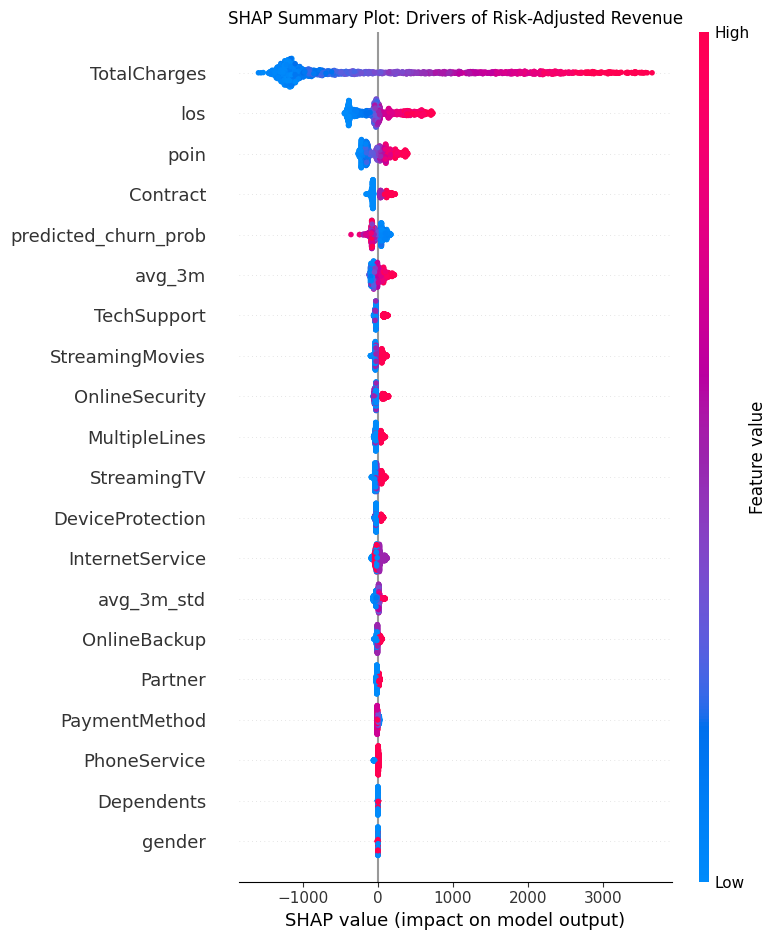

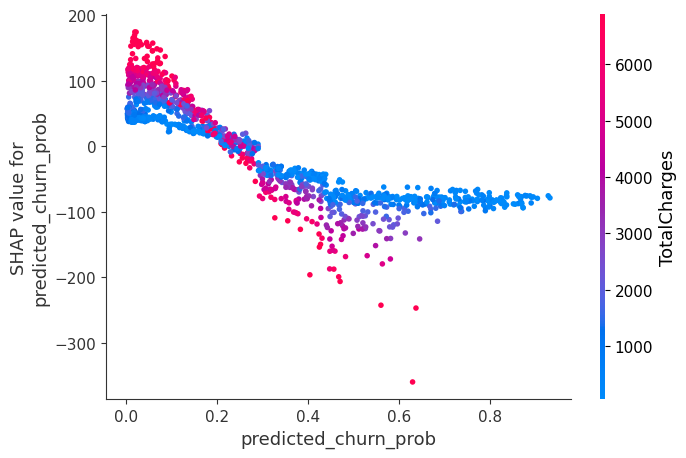

In [5]:
print("Phase 4: Explainability")

explainer = shap.TreeExplainer(cat_model)
shap_values = explainer.shap_values(X_r_test)

plt.figure(figsize=(10, 6))
plt.title("SHAP Summary Plot: Drivers of Risk-Adjusted Revenue")
shap.summary_plot(shap_values, X_r_test, show=False)
plt.tight_layout()
plt.show()

shap.dependence_plot("predicted_churn_prob", shap_values, X_r_test)

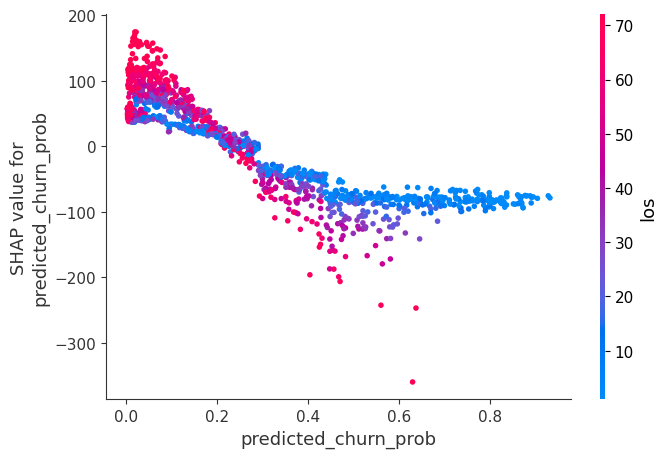

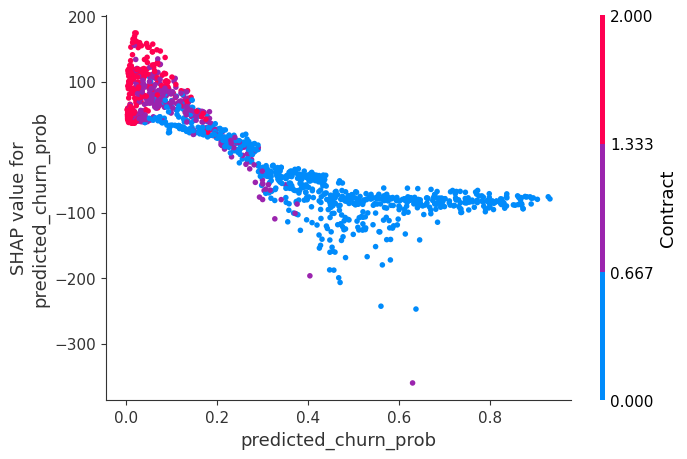

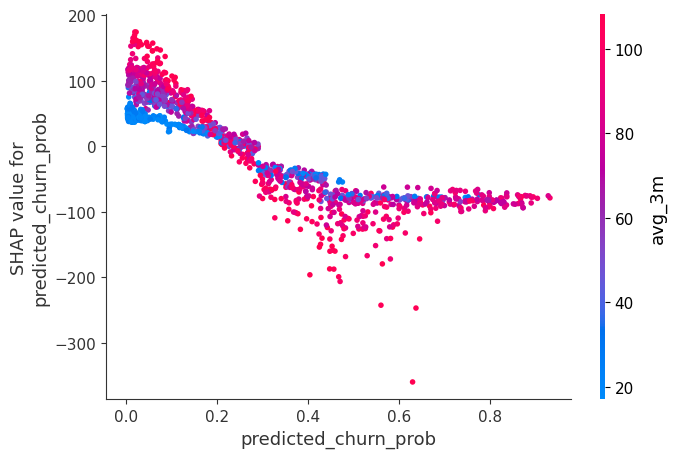

In [10]:
import matplotlib.pyplot as plt

shap.dependence_plot("predicted_churn_prob", shap_values, X_r_test, interaction_index="los")

shap.dependence_plot("predicted_churn_prob", shap_values, X_r_test, interaction_index="Contract")

shap.dependence_plot("predicted_churn_prob", shap_values, X_r_test, interaction_index="avg_3m")